# Пункты a), b), c)

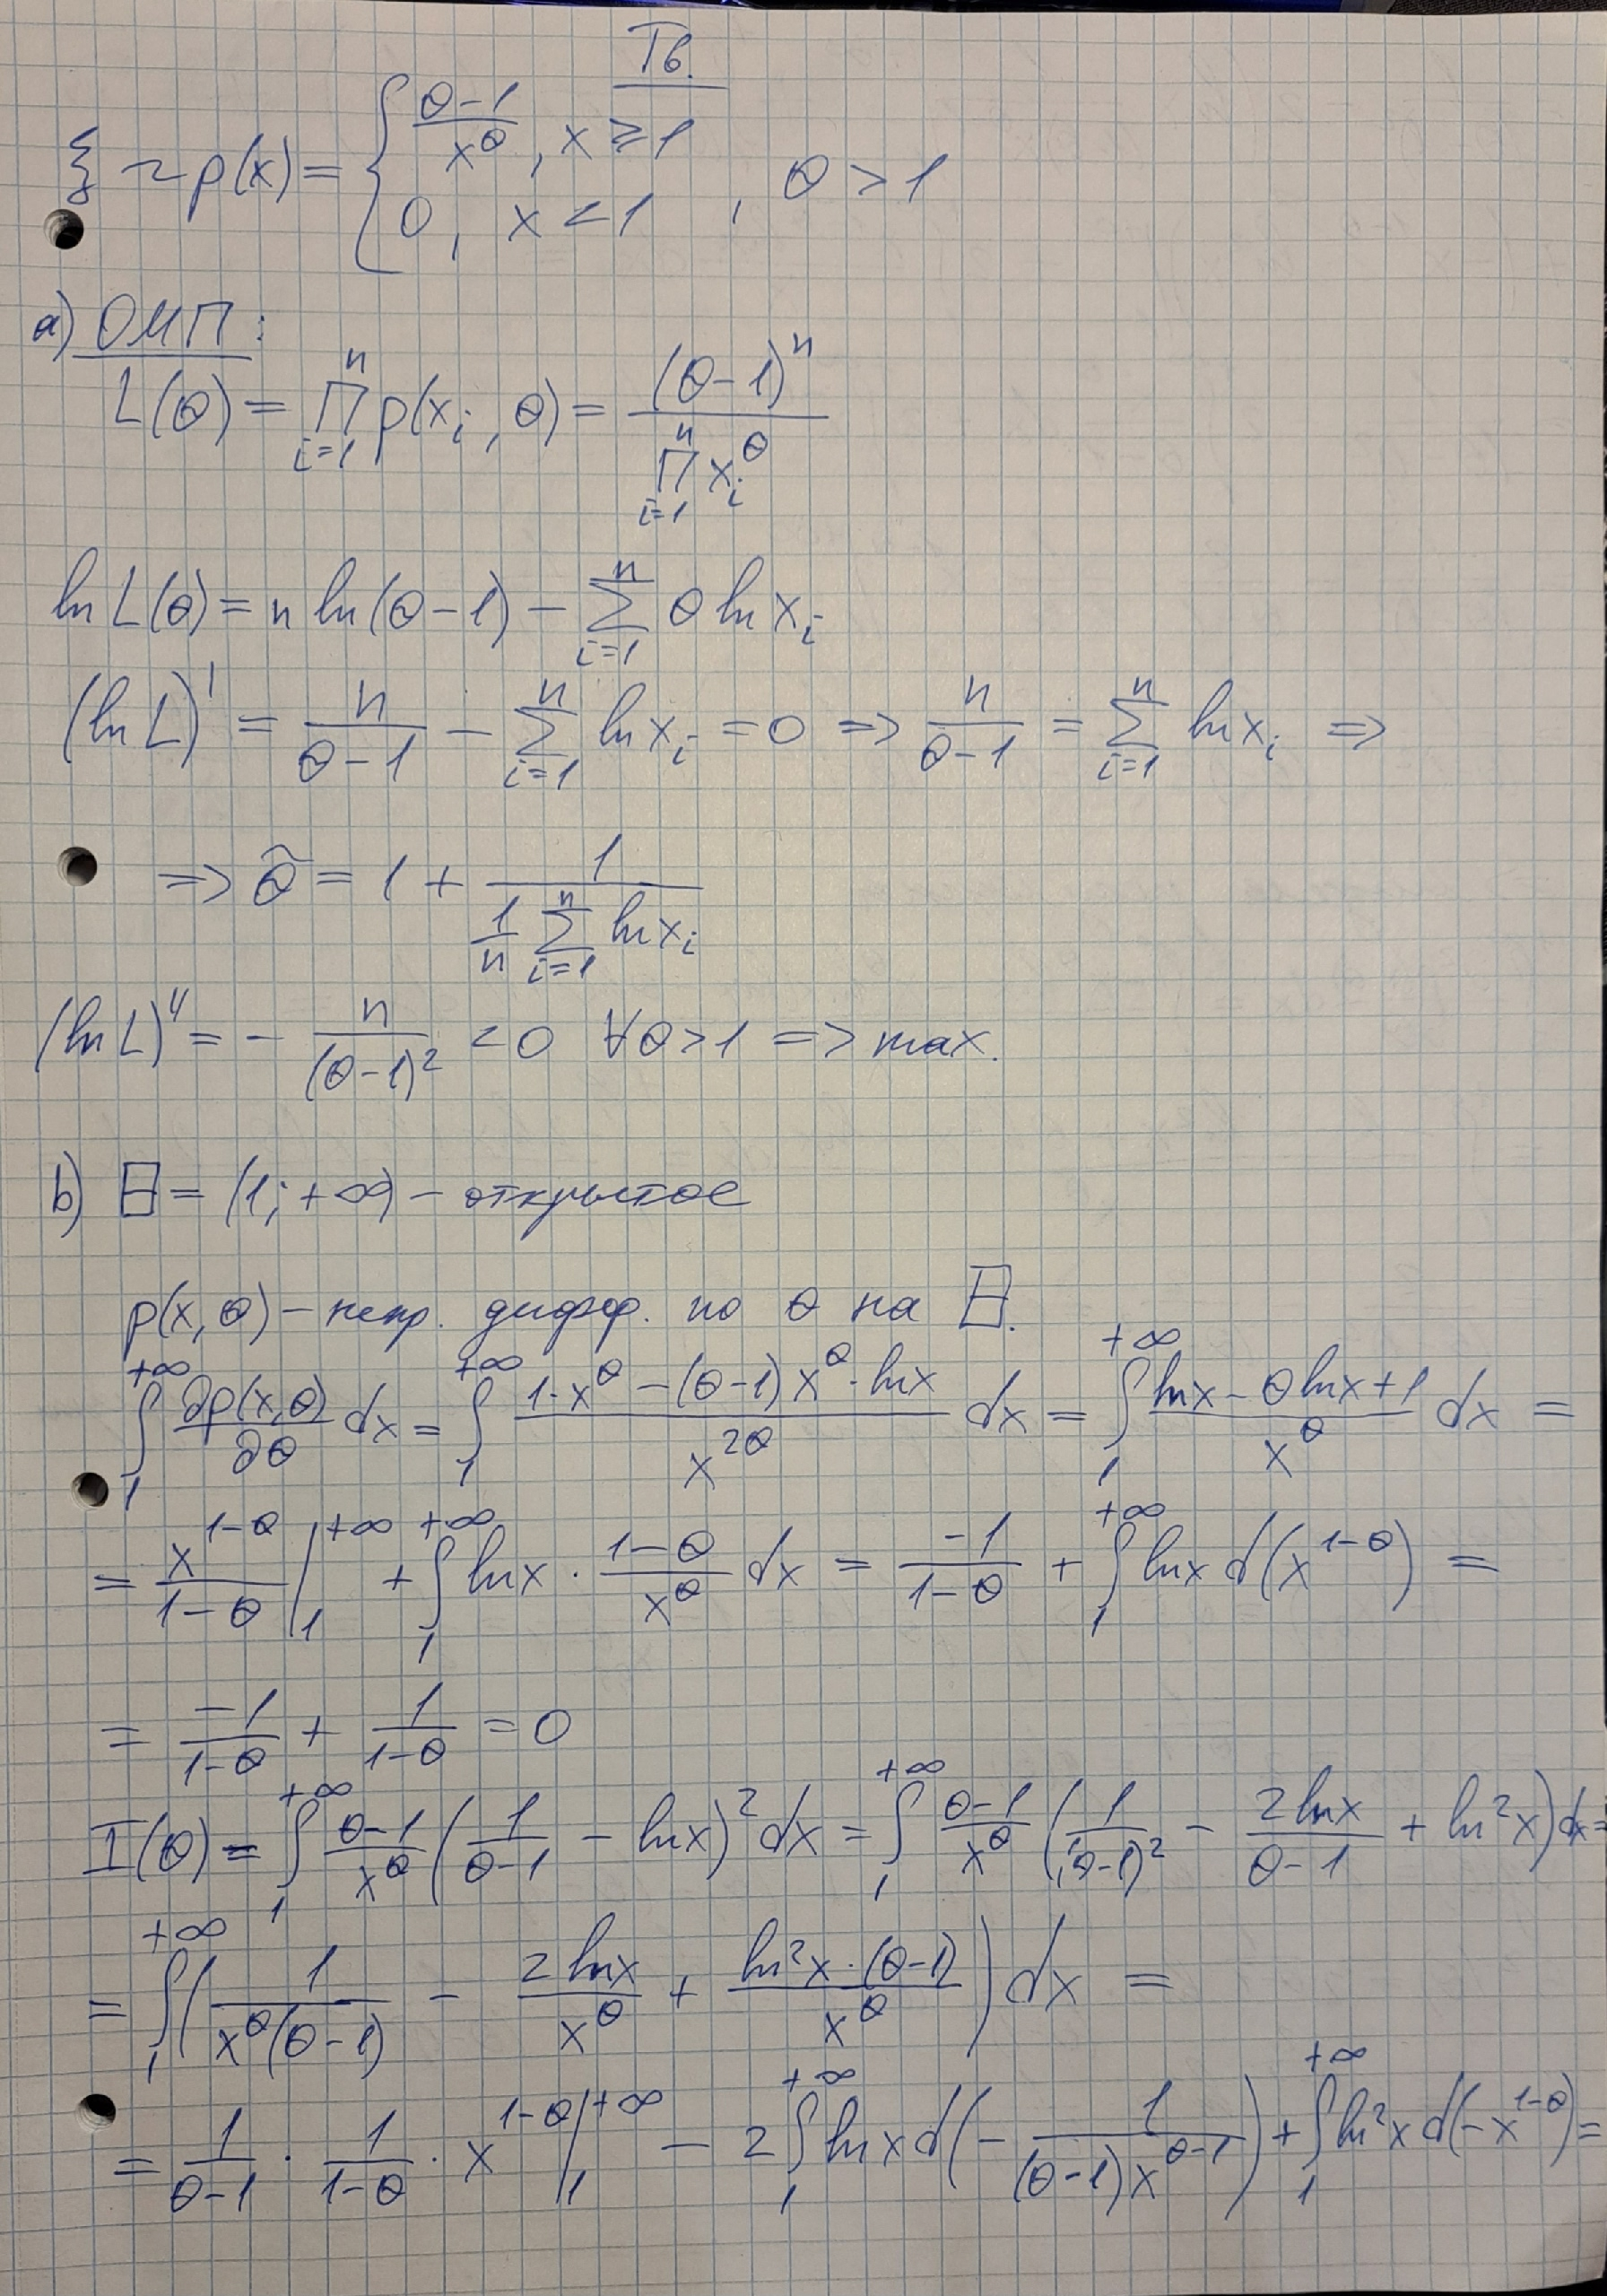

In [547]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import math as mt
plt.style.use("ggplot")

np.random.seed(44)


def pareto(x, theta):
    return (theta - 1) / (x ** theta) if x >= 1 else 0

def pareto_distribution(x, theta):
    return (1 - x) ** (1 / (1 - theta))
  
def parametric_bootstrap(sample, model, statistic, N):
    arr = []
    n = len(sample)
    for _ in range(N):
        new_sample = model(np.random.uniform(0, 1, n))
        arr.append(statistic(new_sample))

    return np.sort(arr)

# Генерация выборки

In [548]:
n = 100
beta = 0.95
# Пусть 
theta = 5
sample = (np.random.pareto(theta - 1, n) + 1) * 1
print("Выборка:", sample)

Выборка: [1.56864689 1.02806248 1.40673401 1.11825283 1.11773321 1.26480049
 1.13329339 1.14055562 1.19516911 1.36287468 2.24348327 1.16472745
 1.14970089 1.03056614 1.06336968 2.2020716  2.04975239 1.70556367
 1.2968065  1.06198936 1.28816979 1.03816804 1.16584633 1.67799064
 1.07761824 1.31428802 1.64271443 1.04111386 1.22989266 1.04428983
 1.04859994 1.02784063 1.05834416 1.16396144 1.48537678 3.2308816
 1.50487672 1.12577191 1.19875318 1.01529193 1.36399096 1.0189959
 1.70841623 1.38224578 1.56516178 1.3629719  1.34832164 1.9448453
 1.70501736 1.02526113 1.16466064 1.18491941 1.02926533 1.04261348
 2.82432536 1.08243438 1.76583824 1.0458729  1.03613154 1.10014776
 1.09618263 1.14690754 1.10571419 1.23352515 1.02534971 1.49159204
 1.08135833 1.83298895 1.78611825 1.00400422 1.61687238 1.32504874
 1.00964839 1.09678699 1.23080861 1.25282166 1.33042023 1.28429717
 2.00973729 1.39656272 1.40703031 1.02923995 1.18545245 1.65513735
 1.00461657 1.05179643 1.03033847 1.61581167 1.01249426 

# d) Вычисление доверительных интервалов из пунктов b) и c)

In [549]:
t1 = U_0_025 = -1.96
t2 = U_0_975 = 1.96

theta_OMP = 1 + n / np.sum(np.log(sample))

med_left = 2 ** (1 / (theta_OMP - 1)) - t2 * (2 ** (1 / (theta_OMP - 1)) * np.log(2)) / ((theta_OMP - 1) * np.sqrt(n))
med_right = 2 ** (1 / (theta_OMP - 1)) - t1 * (2 ** (1 / (theta_OMP - 1)) * np.log(2)) / ((theta_OMP - 1) * np.sqrt(n))
len_med = med_right - med_left

print("Медиана по выборке:", np.mean(sample))
print("Доверительный интервал для медианы:", np.round(med_left, 4), "< median <", np.round(med_right, 4))
print("Длина доверительного интервала для медианы:", np.round(med_right - med_left, 4))

Медиана по выборке: 1.328956839876883
Доверительный интервал для медианы: 1.1507 < median < 1.2326
Длина доверительного интервала для медианы: 0.0819


In [550]:
asympt_left = theta_OMP - t2 * (theta_OMP - 1) / np.sqrt(n)
asympt_right = theta_OMP - t1 * (theta_OMP - 1) / np.sqrt(n)
len_asympt = asympt_right - asympt_left

print("Асимптотический доверительный интервал для theta:", np.round(asympt_left, 4), "< theta <", np.round(asympt_right, 4))
print("Длина асимптотического доверительного интервала для theta:", np.round(len_asympt, 4))

Асимптотический доверительный интервал для theta: 4.1778 < theta < 5.7272
Длина асимптотического доверительного интервала для theta: 1.5494


# t) Построение бутстраповских доверительных интервалов

In [551]:
N = 1000

def statistic(sm):
    return 1 + n / np.sum(np.log(sm))

bt_theta_np = (stats.bootstrap((sample,), statistic, n_resamples=N)).bootstrap_distribution
delta = bt_theta_np - theta_OMP
delta = np.sort(delta)
k1 = int((1 - beta) / 2 * N)
k2 = int((1 + beta) / 2 * N)
bootstrap_left_np = theta_OMP - delta[k2]
bootstrap_right_np = theta_OMP - delta[k1]
len_bootstrap_np = bootstrap_right_np - bootstrap_left_np

print("Бутстраповский непараметрический доверительный интервал для theta:", np.round(bootstrap_left_np, 4), "< theta <", np.round(bootstrap_right_np, 4))
print("Длина бутстраповского непараметрического доверительного интервала для theta:", np.round(len_bootstrap_np, 4))

Бутстраповский непараметрический доверительный интервал для theta: 4.1365 < theta < 5.5976
Длина бутстраповского непараметрического доверительного интервала для theta: 1.461


In [552]:
N = 50000

bt_theta_p = parametric_bootstrap(sample, lambda x: pareto_distribution(x, theta_OMP), statistic, N)
delta = bt_theta_p - theta_OMP
delta = np.sort(delta)
k1 = int((1 - beta) / 2 * N)
k2 = int((1 + beta) / 2 * N)
bootstrap_left_p = theta_OMP - delta[k2]
bootstrap_right_p = theta_OMP - delta[k1]
len_bootstrap_p = bootstrap_right_p - bootstrap_left_p

print("Бутстраповский параметрический доверительный интервал для theta:", np.round(bootstrap_left_p, 4), "< theta <", np.round(bootstrap_right_p, 4))
print("Длина бутстраповского параметрического доверительного интервала для theta:", np.round(len_bootstrap_p, 4))

Бутстраповский параметрический доверительный интервал для theta: 4.0386 < theta < 5.6269
Длина бутстраповского параметрического доверительного интервала для theta: 1.5883


# f) Сравнение интервалов

In [553]:
print("Доверительные интервалы:")
print("Асимптотический для медианы:", np.round(med_left, 4), "< median <", np.round(med_right, 4), "; длина:", np.round(med_right - med_left, 4))
print("Асимптотический:", np.round(asympt_left, 4), "< theta <", np.round(asympt_right, 4), "; длина:", np.round(len_asympt, 4))
print("Бутстраповский непараметрический:", np.round(bootstrap_left_np, 4), "< theta <", np.round(bootstrap_right_np, 4), "; длина:", np.round(len_bootstrap_np, 4))
print("Бутстраповский параметрический:", np.round(bootstrap_left_p, 4), "< theta <", np.round(bootstrap_right_p, 4), "; длина:", np.round(len_bootstrap_p, 4))

Доверительные интервалы:
Асимптотический для медианы: 1.1507 < median < 1.2326 ; длина: 0.0819
Асимптотический: 4.1778 < theta < 5.7272 ; длина: 1.5494
Бутстраповский непараметрический: 4.1365 < theta < 5.5976 ; длина: 1.461
Бутстраповский параметрический: 4.0386 < theta < 5.6269 ; длина: 1.5883
